# SE4050 Deep Learning Assignment
## Notebook 2: Shared Data Preprocessing Pipeline
### Brain Tumor MRI Classification

**IMPORTANT**: Run this notebook once before executing any model notebook (03 through 06).
All model notebooks load the NumPy arrays saved by this pipeline.

---

### Split Strategy

This pipeline pools all available images from both the original `Dataset/Training/`
and `Dataset/Testing/` directories, then applies a single stratified 3-way split:

| Partition | Proportion | Purpose |
|-----------|------------|--------|
| Training  | 70%        | Model optimisation (weights and biases) |
| Validation| 15%        | Hyperparameter tuning and early stopping |
| Test      | 15%        | Final unbiased performance evaluation |

**Rationale**: The original dataset provides a fixed train/test split of approximately 87/13.
Pooling and re-splitting to 70/15/15 provides a more balanced held-out test set
and a dedicated validation partition that was previously absent, enabling reliable
early stopping without contaminating the final test evaluation.

### Outputs saved to `preprocessed_data/`
- `X_train.npy`, `y_train.npy`  — Training set (float32, [0,1], shape N x 224 x 224 x 3)
- `X_val.npy`,   `y_val.npy`    — Validation set
- `X_test.npy`,  `y_test.npy`   — Test set (held out until final evaluation)
- `class_weights.npy`           — Per-class loss weights (balanced strategy)
- `class_names.npy`             — Ordered class name strings
- `preprocessing_config.json`   — Full configuration record for reproducibility

## Section 0: Setup and Configuration

In [1]:
# Standard library
import os
import json
import random
import warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

# Numerical computing
import numpy as np

# Image I/O and resizing
import cv2
from PIL import Image
from tqdm import tqdm

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Suppress non-critical warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------------
# CONFIGURATION — all parameters are defined here for a single point of change
# ------------------------------------------------------------------------------------
CONFIG = {
    'random_seed':   42,          # Fixed seed guarantees identical splits across runs
    'target_size':   (224, 224),  # All models (VGG16, ResNet50, EfficientNetB3) expect 224x224
    'channels':      3,           # RGB (greyscale images are converted to 3-channel)
    'val_size':      0.15,        # 15% of pooled data reserved for validation
    'test_size':     0.15,        # 15% of pooled data reserved for final testing
    # Note: train_size = 1 - val_size - test_size = 0.70 (70%)
    'pixel_scale':   255.0,       # Divide raw pixel values by this to obtain [0, 1]
    'class_weight_strategy': 'balanced',
}

# Apply reproducibility seed to all relevant libraries
random.seed(CONFIG['random_seed'])
np.random.seed(CONFIG['random_seed'])

# ------------------------------------------------------------------------------------
# Directory setup
# ------------------------------------------------------------------------------------
ROOT      = Path('.')
TRAIN_SRC = ROOT / 'Dataset' / 'Training'   # Original training images
TEST_SRC  = ROOT / 'Dataset' / 'Testing'    # Original testing images (pooled into re-split)
OUT_DIR   = ROOT / 'preprocessed_data'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Derive ordered class names from the training directory structure
CLASS_NAMES = sorted([d.name for d in TRAIN_SRC.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

# Accepted image file extensions
VALID_EXTS = {'.jpg', '.jpeg', '.png'}

print('Configuration:')
for k, v in CONFIG.items():
    print(f'  {k:<30}: {v}')
print(f'\nClasses ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Output directory     : {OUT_DIR.resolve()}')


Configuration:
  random_seed                   : 42
  target_size                   : (224, 224)
  channels                      : 3
  val_size                      : 0.15
  test_size                     : 0.15
  pixel_scale                   : 255.0
  class_weight_strategy         : balanced

Classes (4): ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Output directory     : C:\Users\SN Gamalath\Documents\GitHub\SE4050--Deep-Learning-Assignment_Final\preprocessed_data


## Section 1: Build Pooled Image Path List

All image paths and their integer class labels are collected from BOTH the original
Training and Testing source directories. Pooling is necessary so that the subsequent
stratified split is applied across the full dataset, yielding a consistent 70/15/15 partition.

In [2]:
def collect_paths_and_labels(src_dirs: list, class_names: list) -> tuple:
    """
    Recursively collect image file paths and integer class labels from
    one or more source directories.

    Parameters
    ----------
    src_dirs    : List of root directories, each containing one subfolder per class.
    class_names : Ordered list of class folder names; index = integer label.

    Returns
    -------
    paths  : List of Path objects.
    labels : Corresponding list of integer class indices.
    """
    paths, labels = [], []
    for src in src_dirs:
        for cls_idx, cls_name in enumerate(class_names):
            cls_path = src / cls_name
            if not cls_path.exists():
                print(f'  Warning: directory not found: {cls_path}')
                continue
            for fp in sorted(cls_path.iterdir()):
                if fp.suffix.lower() in VALID_EXTS:
                    paths.append(fp)
                    labels.append(cls_idx)
    return paths, labels


# Pool images from both the original Training and Testing directories
all_paths, all_labels = collect_paths_and_labels(
    src_dirs=[TRAIN_SRC, TEST_SRC],
    class_names=CLASS_NAMES
)
all_labels = np.array(all_labels)

# --------- Report pooled dataset composition ---------
total_images = len(all_paths)
print(f'Pooled dataset — total images : {total_images}')
print(f'\nPer-class breakdown (pooled):')
print(f'{"Index":<6} {"Class":<30} {"Count":>7} {"Proportion":>12}')
print('-' * 58)
for idx, cls in enumerate(CLASS_NAMES):
    n   = int((all_labels == idx).sum())
    pct = n / total_images * 100
    print(f'{idx:<6} {cls:<30} {n:>7}  ({pct:>5.1f}%)')
print('-' * 58)
print(f'\nExpected split sizes (70 / 15 / 15):')
print(f'  Training   : ~{int(total_images * 0.70):>5} images')
print(f'  Validation : ~{int(total_images * 0.15):>5} images')
print(f'  Test       : ~{int(total_images * 0.15):>5} images')

Pooled dataset — total images : 3264

Per-class breakdown (pooled):
Index  Class                            Count   Proportion
----------------------------------------------------------
0      glioma_tumor                       926  ( 28.4%)
1      meningioma_tumor                   937  ( 28.7%)
2      no_tumor                           500  ( 15.3%)
3      pituitary_tumor                    901  ( 27.6%)
----------------------------------------------------------

Expected split sizes (70 / 15 / 15):
  Training   : ~ 2284 images
  Validation : ~  489 images
  Test       : ~  489 images


## Section 2: Stratified 70 / 15 / 15 Split

A stratified split preserves the class proportion in each partition, which is
especially important for the minority class (no_tumor). The split is performed
in two steps using `train_test_split` from scikit-learn:

1. Split pooled data into 70% train and 30% temp.
2. Split the 30% temp set into 50% validation and 50% test, yielding 15% each.

In [3]:
# ---------------------------------------------------------------------------
# Step 1: Separate 70% training from the remaining 30%
# ---------------------------------------------------------------------------
# test_size=0.30 here means the TEMP set is 30% of the full dataset
idx_train, idx_temp, y_train_idx, y_temp_idx = train_test_split(
    np.arange(total_images),
    all_labels,
    test_size=0.30,              # 30% goes to temp (will become val + test)
    stratify=all_labels,         # Preserve class proportions in each partition
    random_state=CONFIG['random_seed']
)

# ---------------------------------------------------------------------------
# Step 2: Split the 30% temp set into equal validation and test halves
# This yields 15% validation and 15% test of the full dataset.
# ---------------------------------------------------------------------------
idx_val, idx_test, y_val_idx, y_test_idx = train_test_split(
    idx_temp,
    y_temp_idx,
    test_size=0.50,              # Half of the 30% temp set -> 15% of total
    stratify=y_temp_idx,
    random_state=CONFIG['random_seed']
)

# Resolve path lists for each partition
paths_train = [all_paths[i] for i in idx_train]
paths_val   = [all_paths[i] for i in idx_val]
paths_test  = [all_paths[i] for i in idx_test]

y_train = all_labels[idx_train]
y_val   = all_labels[idx_val]
y_test  = all_labels[idx_test]

# ---------------------------------------------------------------------------
# Verify split proportions and per-class distribution
# ---------------------------------------------------------------------------
print('Split verification:')
print(f'{"Partition":<12} {"N":>6} {"Proportion":>12}')
print('-' * 34)
for name, labels_split in [("Training", y_train), ("Validation", y_val), ("Test", y_test)]:
    n   = len(labels_split)
    pct = n / total_images * 100
    print(f'{name:<12} {n:>6}  ({pct:>5.1f}%)')
print('-' * 34)

print('\nPer-class counts in each partition:')
header = f'{"Class":<25} {"Train":>7} {"Val":>7} {"Test":>7}'
print(header)
print('-' * 48)
for cls_idx, cls in enumerate(CLASS_NAMES):
    n_tr = int((y_train == cls_idx).sum())
    n_va = int((y_val   == cls_idx).sum())
    n_te = int((y_test  == cls_idx).sum())
    print(f'{cls:<25} {n_tr:>7} {n_va:>7} {n_te:>7}')
print('-' * 48)

Split verification:
Partition         N   Proportion
----------------------------------
Training       2284  ( 70.0%)
Validation      490  ( 15.0%)
Test            490  ( 15.0%)
----------------------------------

Per-class counts in each partition:
Class                       Train     Val    Test
------------------------------------------------
glioma_tumor                  648     139     139
meningioma_tumor              656     140     141
no_tumor                      350      75      75
pituitary_tumor               630     136     135
------------------------------------------------


## Section 3: Visualise Split Distribution

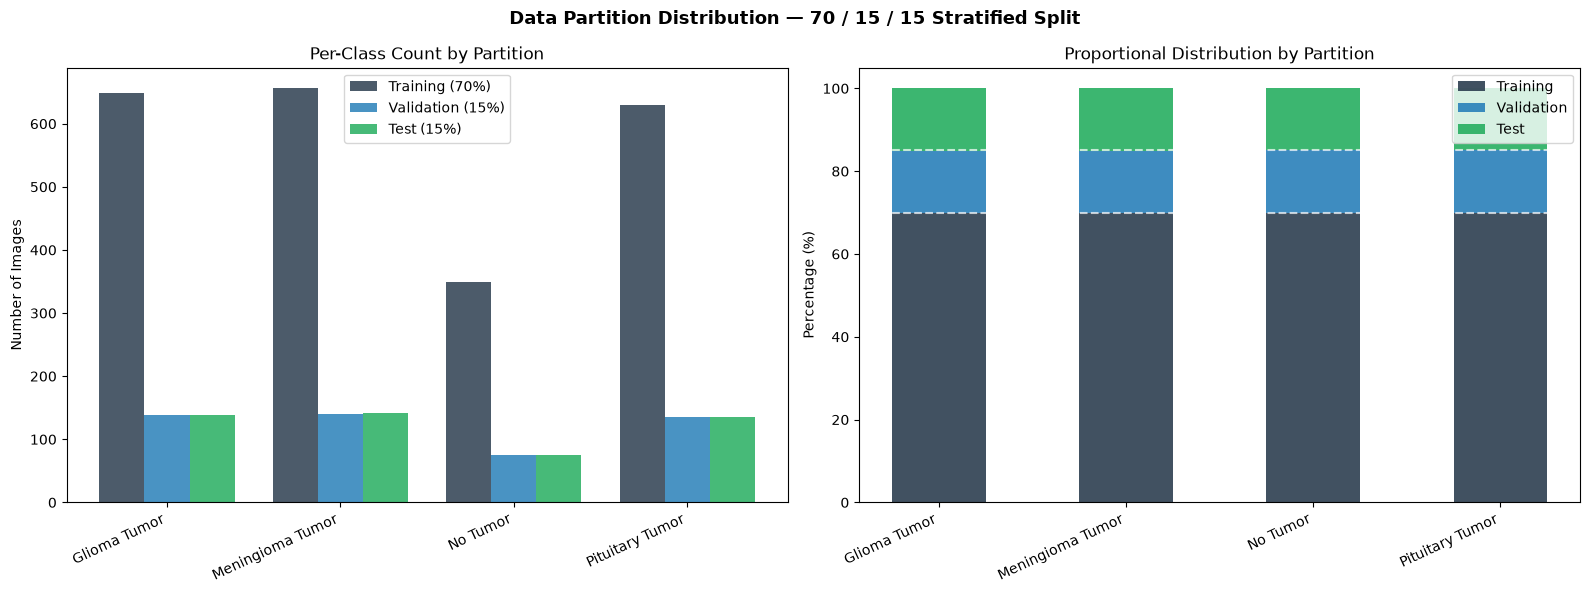

Figure saved to results/preprocessing_split_distribution.png


In [4]:
# ---------------------------------------------------------------------------
# Figure: Bar chart showing per-class image counts in each partition.
# This confirms that stratification preserved class proportions.
# ---------------------------------------------------------------------------
pretty = [c.replace('_', ' ').title() for c in CLASS_NAMES]
CLASS_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
SPLIT_COLORS = ['#2C3E50', '#2980B9', '#27AE60']   # Dark, blue, green

n_train_per_cls = [(y_train == i).sum() for i in range(NUM_CLASSES)]
n_val_per_cls   = [(y_val   == i).sum() for i in range(NUM_CLASSES)]
n_test_per_cls  = [(y_test  == i).sum() for i in range(NUM_CLASSES)]

x     = np.arange(NUM_CLASSES)
width = 0.26

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Data Partition Distribution — 70 / 15 / 15 Stratified Split',
             fontsize=13, fontweight='bold')

# --- Panel A: Grouped bar chart per class per partition ---
ax = axes[0]
b1 = ax.bar(x - width, n_train_per_cls, width, label='Training (70%)',   color=SPLIT_COLORS[0], alpha=0.85)
b2 = ax.bar(x,         n_val_per_cls,   width, label='Validation (15%)', color=SPLIT_COLORS[1], alpha=0.85)
b3 = ax.bar(x + width, n_test_per_cls,  width, label='Test (15%)',       color=SPLIT_COLORS[2], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(pretty, rotation=25, ha='right')
ax.set_ylabel('Number of Images')
ax.set_title('Per-Class Count by Partition')
ax.legend()

# --- Panel B: Proportional stacked bar per class ---
ax = axes[1]
totals = np.array([n_train_per_cls[i] + n_val_per_cls[i] + n_test_per_cls[i]
                   for i in range(NUM_CLASSES)])
p_train = np.array(n_train_per_cls) / totals * 100
p_val   = np.array(n_val_per_cls)   / totals * 100
p_test  = np.array(n_test_per_cls)  / totals * 100

ax.bar(x, p_train, 0.5, label='Training',   color=SPLIT_COLORS[0], alpha=0.9)
ax.bar(x, p_val,   0.5, bottom=p_train,     label='Validation', color=SPLIT_COLORS[1], alpha=0.9)
ax.bar(x, p_test,  0.5, bottom=p_train+p_val, label='Test',     color=SPLIT_COLORS[2], alpha=0.9)
ax.axhline(70, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(85, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(pretty, rotation=25, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 105)
ax.set_title('Proportional Distribution by Partition')
ax.legend()

plt.tight_layout()
plt.savefig('results/preprocessing_split_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved to results/preprocessing_split_distribution.png')

## Section 4: Image Loading and Preprocessing Function

Each image undergoes the following preprocessing steps:
1. Load as BGR using OpenCV (efficient for batch processing)
2. Convert BGR to RGB
3. Convert any grayscale (single-channel) images to 3-channel RGB by replication
4. Resize to 224 x 224 using bilinear interpolation (INTER_AREA for downscaling)
5. Cast to float32 and scale to [0.0, 1.0] by dividing by 255

No model-specific normalisation (e.g., ImageNet mean subtraction) is applied here.
That step is deferred to each model notebook so that these arrays remain universally reusable.

In [5]:
def load_and_preprocess_image(img_path: Path, target_size: tuple) -> np.ndarray:
    """
    Load an image from disk and apply standard preprocessing.

    Steps:
        1. Read image via OpenCV (handles JPEG/PNG efficiently).
        2. Convert BGR channel order to RGB.
        3. If grayscale, replicate single channel to 3 channels.
        4. Resize to `target_size` using area interpolation (best for downscaling).
        5. Normalise pixel values from [0, 255] to [0.0, 1.0].

    Parameters
    ----------
    img_path    : Path to the image file.
    target_size : (width, height) tuple for resizing.

    Returns
    -------
    np.ndarray : Float32 array of shape (target_size[1], target_size[0], 3),
                 with values in [0.0, 1.0]. Returns None on error.
    """
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            # cv2.imread returns None for unsupported files; fall back to PIL
            with Image.open(img_path) as pil_img:
                img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

        # Convert BGR (OpenCV default) to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Ensure 3 channels: convert grayscale to pseudo-RGB via channel replication
        if len(img.shape) == 2 or img.shape[2] == 1:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] == 4:
            # Drop alpha channel for RGBA images
            img = img[:, :, :3]

        # Resize using INTER_AREA for downscaling (minimises aliasing artefacts)
        img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

        # Normalise to [0.0, 1.0]
        img = img.astype(np.float32) / 255.0
        return img

    except Exception as exc:
        print(f'  Error processing {img_path.name}: {exc}')
        return None


# --- Verify the function on a single test image ---
test_path = paths_train[0]
test_img  = load_and_preprocess_image(test_path, CONFIG['target_size'])
print(f'Preprocessing verification:')
print(f'  Input  : {test_path.name}')
print(f'  Output shape : {test_img.shape}')
print(f'  dtype        : {test_img.dtype}')
print(f'  Value range  : [{test_img.min():.4f}, {test_img.max():.4f}]')
print(f'  Mean value   : {test_img.mean():.4f}')

Preprocessing verification:
  Input  : p (693).jpg
  Output shape : (224, 224, 3)
  dtype        : float32
  Value range  : [0.0000, 0.9451]
  Mean value   : 0.1859


## Section 5: Batch Preprocessing — Load All Images into Memory

All images are loaded into NumPy arrays. This avoids repeated disk reads during
training, which would otherwise become a bottleneck on rotating hard drives.

In [6]:
def load_partition(paths: list, labels: np.ndarray,
                   target_size: tuple, partition_name: str,
                   max_workers: int = 8) -> tuple:
    """
    Load and preprocess all images for a given data partition using multi-threaded I/O
    and accelerated batch processing.
    """
    def _worker(item):
        p, lbl = item
        img = load_and_preprocess_image(p, target_size)
        return (img, lbl) if img is not None else None

    items = list(zip(paths, labels))
    images, valid_labels = [], []
    skipped = 0

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        for res in tqdm(
            executor.map(_worker, items),
            total=len(items),
            desc=f'  Loading {partition_name:<12}',
            unit='img'
        ):
            if res is not None:
                images.append(res[0])
                valid_labels.append(res[1])
            else:
                skipped += 1

    if skipped > 0:
        print(f'  Warning: {skipped} images could not be loaded and were skipped.')

    X = np.array(images,       dtype=np.float32)
    y = np.array(valid_labels, dtype=np.int64)
    return X, y


print('Loading training set (accelerated parallel I/O)...')
X_train, y_train_final = load_partition(paths_train, y_train, CONFIG['target_size'], 'Training')

print('Loading validation set (accelerated parallel I/O)...')
X_val, y_val_final = load_partition(paths_val, y_val, CONFIG['target_size'], 'Validation')

print('Loading test set (accelerated parallel I/O)...')
X_test, y_test_final = load_partition(paths_test, y_test, CONFIG['target_size'], 'Test')

# ------------- Summary of loaded arrays -------------------
print('\nLoaded array summary:')
print(f'{"Partition":<12} {"X shape":<25} {"y shape":<15} {"Memory":>10}')
print('-' * 68)
for name, X, y in [("Training",   X_train, y_train_final),
                   ("Validation", X_val,   y_val_final),
                   ("Test",       X_test,  y_test_final)]:
    mem_mb = X.nbytes / 1024 / 1024
    print(f'{name:<12} {str(X.shape):<25} {str(y.shape):<15} {mem_mb:>8.1f} MB')
print('-' * 68)


Loading training set (accelerated parallel I/O)...


  Loading Training    : 100%|██████████| 2284/2284 [00:01<00:00, 2137.28img/s]


Loading validation set (accelerated parallel I/O)...


  Loading Validation  : 100%|██████████| 490/490 [00:00<00:00, 2060.49img/s]


Loading test set (accelerated parallel I/O)...


  Loading Test        : 100%|██████████| 490/490 [00:00<00:00, 1887.01img/s]



Loaded array summary:
Partition    X shape                   y shape             Memory
--------------------------------------------------------------------
Training     (2284, 224, 224, 3)       (2284,)           1311.5 MB
Validation   (490, 224, 224, 3)        (490,)             281.4 MB
Test         (490, 224, 224, 3)        (490,)             281.4 MB
--------------------------------------------------------------------


## Section 6: Class Weight Computation

Class weights are computed from the TRAINING labels only (not validation or test),
as they represent the distribution the model will be optimised on.
The balanced strategy sets weight inversely proportional to class frequency.

In [7]:
# Compute balanced class weights from the training partition labels only.
# Formula: weight_c = N_total / (N_classes * N_c)
# where N_c is the number of training samples for class c.
class_weights = compute_class_weight(
    class_weight=CONFIG['class_weight_strategy'],
    classes=np.unique(y_train_final),
    y=y_train_final
)
class_weights = class_weights.astype(np.float32)

print('Class weights (training partition):')
print(f'{"Index":<6} {"Class":<25} {"Train Count":>12} {"Weight":>10}')
print('-' * 56)
for idx, cls in enumerate(CLASS_NAMES):
    count  = int((y_train_final == idx).sum())
    weight = class_weights[idx]
    print(f'{idx:<6} {cls:<25} {count:>12} {weight:>10.4f}')
print('-' * 56)
print('\nWeights > 1.0 upweight the minority class during loss computation.')
print('These weights are passed to the CrossEntropyLoss criterion in each model notebook.')

Class weights (training partition):
Index  Class                      Train Count     Weight
--------------------------------------------------------
0      glioma_tumor                       648     0.8812
1      meningioma_tumor                   656     0.8704
2      no_tumor                           350     1.6314
3      pituitary_tumor                    630     0.9063
--------------------------------------------------------

Weights > 1.0 upweight the minority class during loss computation.
These weights are passed to the CrossEntropyLoss criterion in each model notebook.


## Section 7: Quality Checks on Loaded Arrays

In [8]:
# ---------------------------------------------------------------------------
# Sanity checks before saving:
#   1. Value range must be strictly [0.0, 1.0]
#   2. No NaN or Inf values (would corrupt gradient computation)
#   3. Shape must be (N, 224, 224, 3)
#   4. Labels must fall within [0, NUM_CLASSES - 1]
# ---------------------------------------------------------------------------
all_passed = True

for name, X, y in [("Training",   X_train, y_train_final),
                   ("Validation", X_val,   y_val_final),
                   ("Test",       X_test,  y_test_final)]:

    issues = []

    # Check 1: value range
    if X.min() < 0.0 or X.max() > 1.0:
        issues.append(f'Pixel range [{X.min():.4f}, {X.max():.4f}] outside [0, 1]')

    # Check 2: no NaN or Inf
    if np.isnan(X).any() or np.isinf(X).any():
        issues.append('X contains NaN or Inf values')

    # Check 3: correct spatial shape
    target_h, target_w = CONFIG['target_size'][1], CONFIG['target_size'][0]
    if X.shape[1] != target_h or X.shape[2] != target_w or X.shape[3] != 3:
        issues.append(f'Unexpected shape: {X.shape}')

    # Check 4: valid label range
    if y.min() < 0 or y.max() >= NUM_CLASSES:
        issues.append(f'Labels out of range: [{y.min()}, {y.max()}]')

    status = 'PASS' if not issues else f'FAIL: {issues}'
    print(f'  [{name:<12}] {status}')
    if issues:
        all_passed = False

if all_passed:
    print('\nAll quality checks passed. Proceeding to save.')
else:
    print('\nQuality checks failed. Review the issues above before continuing.')


  [Training    ] PASS
  [Validation  ] PASS
  [Test        ] PASS

All quality checks passed. Proceeding to save.


## Section 8: Save Preprocessed Arrays to Disk

Arrays are saved in NumPy binary format (`.npy`) for fast, lossless I/O.
A JSON configuration file is saved alongside the arrays to fully document
the preprocessing parameters for reproducibility.

In [9]:
import time

if not all_passed:
    raise RuntimeError('Quality checks failed. Fix the issues above before saving.')

print('Saving preprocessed arrays...')
t_start = time.time()

# Save image arrays
np.save(OUT_DIR / 'X_train.npy', X_train)
np.save(OUT_DIR / 'X_val.npy',   X_val)
np.save(OUT_DIR / 'X_test.npy',  X_test)

# Save label arrays
np.save(OUT_DIR / 'y_train.npy', y_train_final)
np.save(OUT_DIR / 'y_val.npy',   y_val_final)
np.save(OUT_DIR / 'y_test.npy',  y_test_final)

# Save class weights (used by CrossEntropyLoss in model notebooks)
np.save(OUT_DIR / 'class_weights.npy', class_weights)

# Save class names as an object array for consistent ordering
np.save(OUT_DIR / 'class_names.npy', np.array(CLASS_NAMES, dtype=object))

# Save the full configuration as a JSON record for provenance tracking
config_record = {
    'description': 'SE4050 Preprocessing Configuration',
    'random_seed':        CONFIG['random_seed'],
    'target_size':        list(CONFIG['target_size']),
    'channels':           CONFIG['channels'],
    'pixel_scale':        CONFIG['pixel_scale'],
    'train_proportion':   0.70,
    'val_proportion':     0.15,
    'test_proportion':    0.15,
    'class_weight_strategy': CONFIG['class_weight_strategy'],
    'class_names':        CLASS_NAMES,
    'class_weights':      class_weights.tolist(),
    'split_sizes': {
        'train': int(len(X_train)),
        'val':   int(len(X_val)),
        'test':  int(len(X_test)),
    },
    'per_class_train_counts': {CLASS_NAMES[i]: int((y_train_final == i).sum())
                               for i in range(NUM_CLASSES)},
    'per_class_val_counts':   {CLASS_NAMES[i]: int((y_val_final   == i).sum())
                               for i in range(NUM_CLASSES)},
    'per_class_test_counts':  {CLASS_NAMES[i]: int((y_test_final  == i).sum())
                               for i in range(NUM_CLASSES)},
    'normalization_note': (
        'Arrays are normalised to [0, 1] only. Model-specific normalisation '
        '(ImageNet mean subtraction) is applied inside each model notebook.'
    ),
    'source_directories': [str(TRAIN_SRC.resolve()), str(TEST_SRC.resolve())],
}

with open(OUT_DIR / 'preprocessing_config.json', 'w') as f:
    json.dump(config_record, f, indent=2)

elapsed = time.time() - t_start

print(f'\nAll files saved to: {OUT_DIR.resolve()}')
print(f'Save time: {elapsed:.1f} s')
print('\nSaved files:')
for fp in sorted(OUT_DIR.iterdir()):
    size_mb = fp.stat().st_size / 1024 / 1024
    print(f'  {fp.name:<35} {size_mb:>7.1f} MB')

Saving preprocessed arrays...

All files saved to: C:\Users\SN Gamalath\Documents\GitHub\SE4050--Deep-Learning-Assignment_Final\preprocessed_data
Save time: 2.3 s

Saved files:
  class_names.npy                         0.0 MB
  class_weights.npy                       0.0 MB
  preprocessing_config.json               0.0 MB
  X_test.npy                            281.4 MB
  X_train.npy                          1311.5 MB
  X_val.npy                             281.4 MB
  y_test.npy                              0.0 MB
  y_train.npy                             0.0 MB
  y_val.npy                               0.0 MB


## Section 9: Visual Verification of Saved Arrays

Reload verification:
  X_train loaded shape: (2284, 224, 224, 3)
  Value range         : [0.0000, 1.0000]
  dtype               : float32


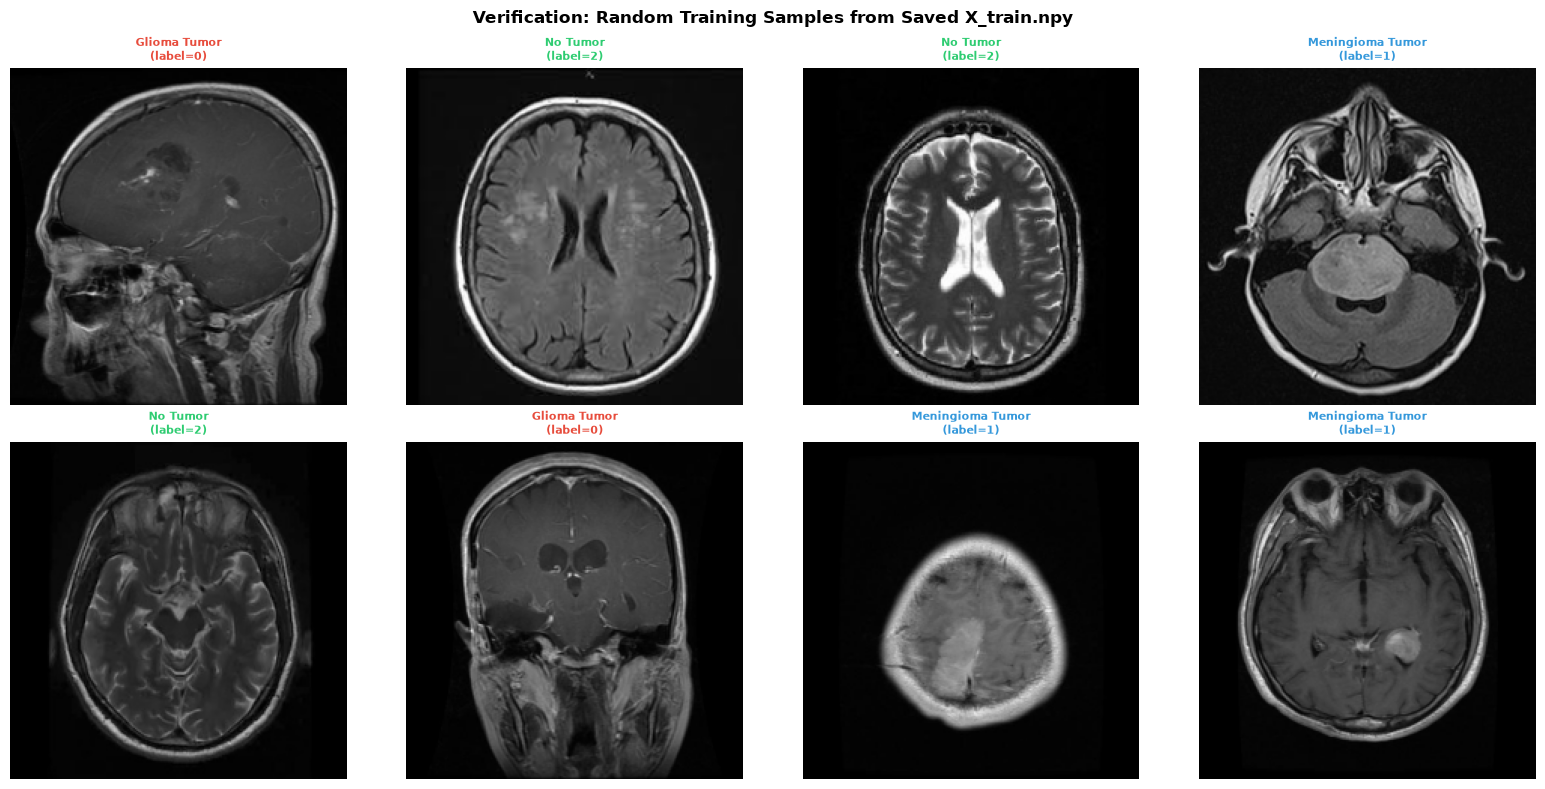

Preprocessing pipeline complete.
Model notebooks (03 through 06) may now be executed in any order.


In [10]:
# ---------------------------------------------------------------------------
# Reload the saved arrays from disk and display a random sample to confirm
# that the save/load cycle preserves image content and labels correctly.
# ---------------------------------------------------------------------------
X_loaded = np.load(OUT_DIR / 'X_train.npy')
y_loaded = np.load(OUT_DIR / 'y_train.npy')

print('Reload verification:')
print(f'  X_train loaded shape: {X_loaded.shape}')
print(f'  Value range         : [{X_loaded.min():.4f}, {X_loaded.max():.4f}]')
print(f'  dtype               : {X_loaded.dtype}')

# Display 8 random training samples from the loaded array
rng     = np.random.RandomState(CONFIG['random_seed'])
indices = rng.choice(len(X_loaded), 8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Verification: Random Training Samples from Saved X_train.npy',
             fontsize=12, fontweight='bold')
for ax, idx in zip(axes.flat, indices):
    img   = X_loaded[idx]        # float32 in [0, 1]
    label = int(y_loaded[idx])
    # Clip to [0, 1] for display safety (should already be in range)
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(
        f'{CLASS_NAMES[label].replace("_", " ").title()}\n'
        f'(label={label})',
        fontsize=8, fontweight='bold',
        color=['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6'][label]
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('results/preprocessing_sample_verification.png', bbox_inches='tight', dpi=150)
plt.show()

print('Preprocessing pipeline complete.')
print('Model notebooks (03 through 06) may now be executed in any order.')

## Section 10: Preprocessing Summary

| Step | Parameter | Value |
|------|-----------|-------|
| Target image size | Resize (W x H) | 224 x 224 px |
| Channel format | Colour mode | 3-channel RGB |
| Pixel normalisation | Scale | Divide by 255 -> [0.0, 1.0] |
| Random seed | Reproducibility | 42 |
| Split strategy | Stratified k-fold (k=2 step) | 70 / 15 / 15 |
| Class weighting | Strategy | sklearn balanced |
| Source directories | Pooled from | Training + Testing |
| Storage format | NumPy binary | .npy |

The saved `X_*.npy` arrays contain general-purpose normalised images.
Each model notebook applies its own backbone-specific normalisation
(e.g., ImageNet channel mean subtraction) through its DataLoader transform,
keeping these baseline arrays architecture-agnostic.